#COMP 6781 Project - NLP Bois

Firstly I download the important libraries and also download the Hate Speech and Offensive Language Dataset from  https://www.kaggle.com/datasets/mrmorj/hate-speech-and-offensive-language-dataset/data

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [ ]:
!pip install kaggle

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mrmorj/hate-speech-and-offensive-language-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.01M/1.01M [00:00<00:00, 95.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mrmorj/hate-speech-and-offensive-language-dataset/versions/1


In [ ]:
# I get the path to the dataset and then load the csv file
dataset_path = "/root/.cache/kagglehub/datasets/mrmorj/hate-speech-and-offensive-language-dataset/versions/1"

for file in os.listdir(dataset_path):
    if file.endswith('.csv'):
        file_path = os.path.join(dataset_path, file)
        hate_speech = pd.read_csv(file_path)
        print(f"Loaded: {file}")
        break






Loaded: labeled_data.csv


I then examine the loaded dataset - hate_speech and see some rows from it

In [ ]:

print(f"Dataset shape: {hate_speech.shape}")
print(f"Number of rows: {hate_speech.shape[0]:,}")
print(f"Number of columns: {hate_speech.shape[1]}")

print("\n Column names and data types:")
print(hate_speech.dtypes)

print("\nFirst 5 rows:")
print(hate_speech.head())

print("\n Last 5 rows:")
print(hate_speech.tail())

Dataset shape: (24783, 7)
Number of rows: 24,783
Number of columns: 7

 Column names and data types:
Unnamed: 0             int64
count                  int64
hate_speech            int64
offensive_language     int64
neither                int64
class                  int64
tweet                 object
dtype: object

First 5 rows:
   Unnamed: 0  count  hate_speech  offensive_language  neither  class  \
0           0      3            0                   0        3      2   
1           1      3            0                   3        0      1   
2           2      3            0                   3        0      1   
3           3      3            0                   2        1      1   
4           4      6            0                   6        0      1   

                                               tweet  
0  !!! RT @mayasolovely: As a woman you shouldn't...  
1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...  
2  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...  
3  !!!!!

As we can see from above only the **class** and the **tweet** column are relevant for our project thus we remove the rest of the columns

In [ ]:
columns_to_keep = ['tweet', 'class']
hate_speech = hate_speech[columns_to_keep]
print(hate_speech.head())

                                               tweet  class
0  !!! RT @mayasolovely: As a woman you shouldn't...      2
1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...      1
2  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...      1
3  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...      1
4  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...      1


I then check for missing values just in case

In [ ]:
print(hate_speech.isnull().sum())

print(f"\nTotal missing values: {hate_speech.isnull().sum().sum()}")
print(f"Dataset shape: {hate_speech.shape}")

tweet    0
class    0
dtype: int64

Total missing values: 0
Dataset shape: (24783, 2)


Fortunately no missing values are there so next I explore the tweet column since it's the most important for us in terms of cleaning and preprocessing and see what characters and symbols to remove along with checking the class distribution in the dataset

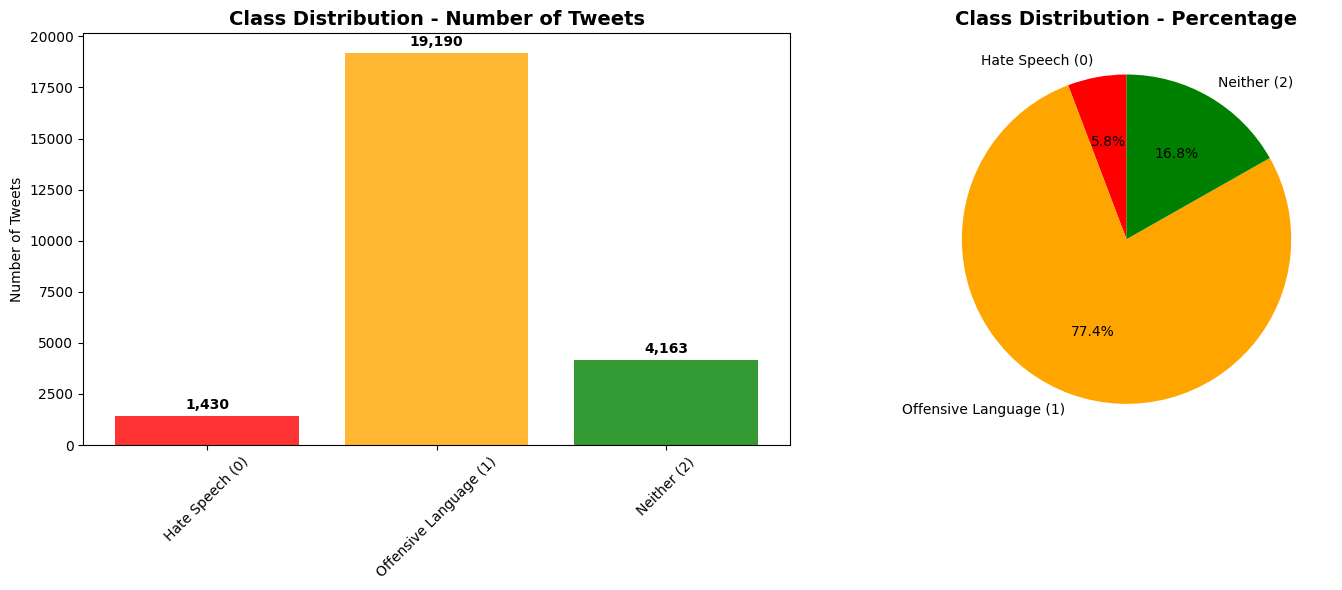

In [ ]:


plt.style.use('default')
sns.set_palette("husl")


class_counts = hate_speech['class'].value_counts().sort_index()
class_percentages = (hate_speech['class'].value_counts(normalize=True).sort_index() * 100).round(2)


class_data = {
    'Class': ['Hate Speech (0)', 'Offensive Language (1)', 'Neither (2)'],
    'Count': [class_counts[0], class_counts[1], class_counts[2]],
    'Percentage': [class_percentages[0], class_percentages[1], class_percentages[2]]
}

df_class = pd.DataFrame(class_data)


fig, axes = plt.subplots(1, 2, figsize=(15, 6))


axes[0].bar(df_class['Class'], df_class['Count'], color=['red', 'orange', 'green'], alpha=0.8)
axes[0].set_title('Class Distribution - Number of Tweets', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Tweets')
axes[0].tick_params(axis='x', rotation=45)

for i, count in enumerate(df_class['Count']):
    axes[0].text(i, count + max(df_class['Count'])*0.01, f'{count:,}', ha='center', va='bottom', fontweight='bold')


colors = ['red', 'orange', 'green']
axes[1].pie(df_class['Count'], labels=df_class['Class'], autopct='%1.1f%%',
           colors=colors, startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Class Distribution - Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


As we can observe from above that the dataset is highly imbalanced with the Offensive Language Class being 77% of the entire dataset , meaning that the model can simply just guess Offensive Language all the time and still be correct majority of the cases , thus looking at the more than sufficient overrrepresented Offensive Language Class I believe undersampling it would be appropriate

BEFORE BALANCING:
Hate Speech (0): 1,430
Offensive Language (1): 19,190
Neither (2): 4,163

AFTER BALANCING:
Class 0: 1,430 tweets
Class 1: 6,244 tweets
Class 2: 4,163 tweets


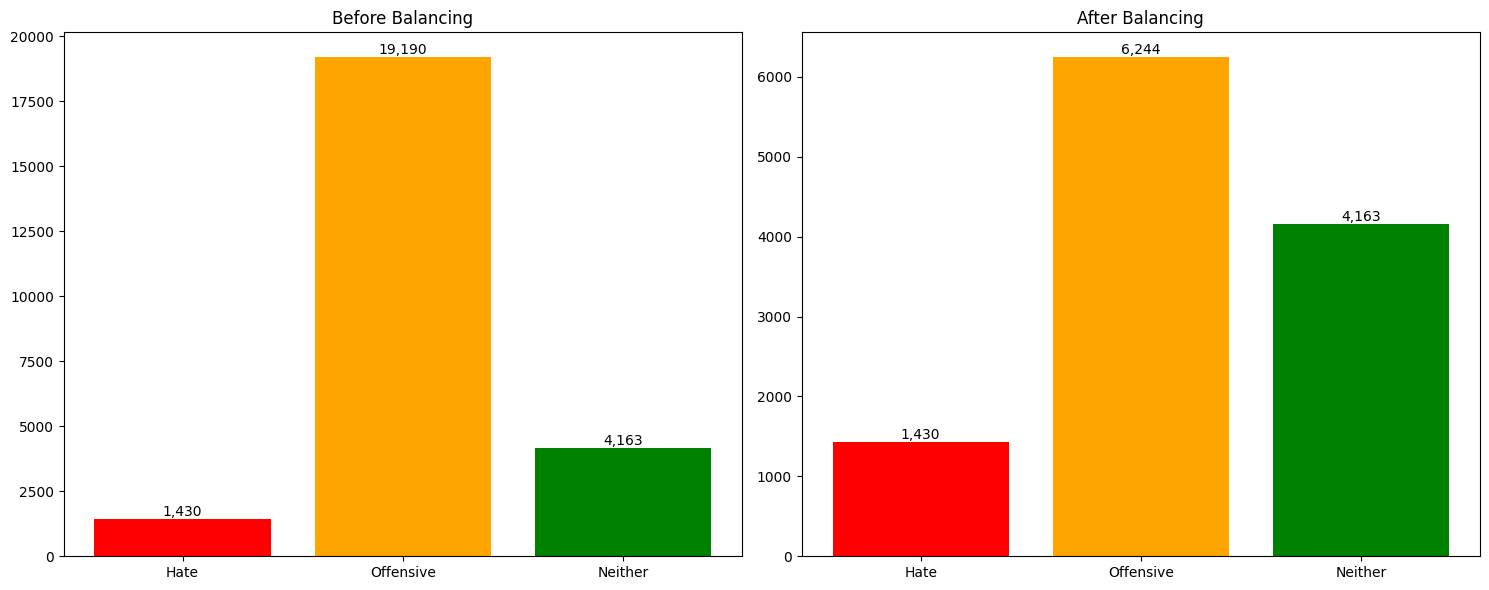

In [ ]:
from sklearn.utils import resample

df_hate = hate_speech[hate_speech['class'] == 0]
df_offensive = hate_speech[hate_speech['class'] == 1]
df_neither = hate_speech[hate_speech['class'] == 2]

print("BEFORE BALANCING:")
print(f"Hate Speech (0): {len(df_hate):,}")
print(f"Offensive Language (1): {len(df_offensive):,}")
print(f"Neither (2): {len(df_neither):,}")

target_size = int(len(df_neither) * 1.5)

df_offensive_balanced = resample(df_offensive,
                                replace=False,
                                n_samples=target_size,
                                random_state=42)

df_balanced = pd.concat([df_hate, df_offensive_balanced, df_neither])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nAFTER BALANCING:")
balanced_counts = df_balanced['class'].value_counts().sort_index()
for class_val, count in balanced_counts.items():
    print(f"Class {class_val}: {count:,} tweets")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

original_counts = hate_speech['class'].value_counts().sort_index()
axes[0].bar(['Hate', 'Offensive', 'Neither'], original_counts.values, color=['red', 'orange', 'green'])
axes[0].set_title('Before Balancing')
for i, count in enumerate(original_counts):
    axes[0].text(i, count, f'{count:,}', ha='center', va='bottom')

axes[1].bar(['Hate', 'Offensive', 'Neither'], balanced_counts.values, color=['red', 'orange', 'green'])
axes[1].set_title('After Balancing')
for i, count in enumerate(balanced_counts):
    axes[1].text(i, count, f'{count:,}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

hate_speech_balanced = df_balanced



```
# This is formatted as code
```

Now the dataset is more balanced than before and we also made sure we didn't loose too much of the Offensive Language class samples after undersampling , but still later weights will be necessary and accuracy will be misleading due to the still slight overabundance of the Offensive Language class

Now I check what characters and symbols are there in the tweets to remove

In [ ]:
import re
from collections import Counter


def analyze_tweet_content(text_series, sample_size=8000):
    sample_texts = text_series.sample(min(sample_size, len(text_series)), random_state=42)
    all_text = ' '.join(sample_texts.astype(str))


    urls = re.findall(r'https?://\S+|www\.\S+', all_text)
    mentions = re.findall(r'@\w+', all_text)
    hashtags = re.findall(r'#\w+', all_text)
    symbols = re.findall(r'[^\w\s@#]', all_text)
    emojis = re.findall(r'[^\x00-\x7F]+', all_text)
    rt_patterns = re.findall(r'\bRT\b', all_text, re.IGNORECASE)

    print("CONTENT ANALYSIS:")
    print(f"URLs: {len(set(urls))} unique")
    print(f"Mentions: {len(set(mentions))} unique")
    print(f"Hashtags: {len(set(hashtags))} unique")
    print(f"Special symbols: {len(set(symbols))} unique")
    print(f"Emojis: {len(set(emojis))} unique")
    print(f"RT patterns: {len(rt_patterns)} total")

    return len(set(urls)), len(set(mentions)), len(set(hashtags))


urls_count, mentions_count, hashtags_count = analyze_tweet_content(hate_speech_balanced['tweet'])



CONTENT ANALYSIS:
URLs: 1157 unique
Mentions: 5075 unique
Hashtags: 1420 unique
Special symbols: 26 unique
Emojis: 0 unique
RT patterns: 2420 total


As we can see from the above analysis , there are plenty of URLs,mentions and #s to remove from the dataset, as we don't them to be part of the vocabulary nor to play a part in the models thus basically I only want to keep the English characters and turn all the tweets to lowercase to standardise them

In [ ]:
def clean_tweet_for_mnb(tweet):
    if not isinstance(tweet, str):
        return ""

    tweet = tweet.lower()

    # Remove URLs
    tweet = re.sub(r'https?://\S+|www\.\S+', '', tweet)

    # Remove mentions
    tweet = re.sub(r'@\w+', '', tweet)

    # Remove hashtags but keep the text
    tweet = re.sub(r'#(\w+)', r'\1', tweet)

    # Remove RT indicators
    tweet = re.sub(r'\brt\b', '', tweet)

    # Keep only English alphabets (lowercase) spaces
    tweet = re.sub(r'[^a-z\s]', '', tweet)

    # Remove extra whitespace
    tweet = re.sub(r'\s+', ' ', tweet)
    return tweet.strip()

# Apply cleaning
hate_speech_char_rem = hate_speech_balanced.copy()
hate_speech_char_rem['cleaned_tweet'] = hate_speech_char_rem['tweet'].apply(clean_tweet_for_mnb)

# Compare samples
print("BEFORE vs AFTER CLEANING:")
for i in range(3):
    print(f"\nSample {i+1}:")
    print(f"BEFORE: {hate_speech_char_rem['tweet'].iloc[i]}")
    print(f"AFTER:  {hate_speech_char_rem['cleaned_tweet'].iloc[i]}")


BEFORE vs AFTER CLEANING:

Sample 1:
BEFORE: @EntMagazine @magisto @digitalskeptic we have a project that could lead into a military program but requires a full op mock up for testing
AFTER:  we have a project that could lead into a military program but requires a full op mock up for testing

Sample 2:
BEFORE: My best friend loves Justin beiber what a fag &#128557;&#128514;&#128557; @Cryystalina
AFTER:  my best friend loves justin beiber what a fag

Sample 3:
BEFORE: RT @Brittanny188: Pull up on my ex make that bitch mad&#128514;&#128514;&#128128;&#128128;
AFTER:  pull up on my ex make that bitch mad


Now I again only keep the cleaned_tweet and the class columns from the **hate_speech_char_rem dataset**

In [ ]:
hate_speech_char_rem = hate_speech_char_rem[['cleaned_tweet', 'class']]
print(hate_speech_char_rem.head())

                                       cleaned_tweet  class
0  we have a project that could lead into a milit...      2
1      my best friend loves justin beiber what a fag      0
2               pull up on my ex make that bitch mad      1
3  ive met few people in politics that i disrespe...      2
4  this guys company had best year everunder obam...      2


Now I want to filter out closed class words/stop words as they carry little meaning like prepositions and determiners etc.. also knowing that I removed all punctuations I am accounting for stopwords like **ive** and **hes** also seperately

In [ ]:
import nltk
from nltk.corpus import stopwords


nltk.download('stopwords')

def remove_stopwords(text):
    if not isinstance(text, str):
        return ""


    stop_words = set(stopwords.words('english'))

    # Additional words to remove (contractions without punctuation)
    additional_stopwords = {
        'im', 'ive', 'id', 'ill', 'hes', 'hed','shes', 'shed', 'shell',
        'were', 'wed', 'well', 'theyre', 'theyd', 'theyll', 'thats', 'thatll',
        'whos', 'whod', 'wholl', 'whats', 'whatre', 'whens', 'wheres', 'whys',
        'hows', 'cant', 'dont', 'wont', 'shouldnt', 'couldnt', 'wouldnt',
        'isnt', 'arent', 'wasnt', 'werent', 'hasnt', 'havent', 'hadnt'
    }

    stop_words.update(additional_stopwords)


    words = text.split()
    filtered_words = [word for word in words if word not in stop_words and len(word) > 1]

    return ' '.join(filtered_words)

hate_speech_stop = hate_speech_char_rem.copy()
hate_speech_stop['cleaned_tweet'] = hate_speech_stop['cleaned_tweet'].apply(remove_stopwords)

# Compare samples before and after stop word removal
print("BEFORE vs AFTER STOP WORD REMOVAL:")
for i in range(3):
    print(f"\nSample {i+1}:")

    before_stopwords = hate_speech_char_rem['cleaned_tweet'].iloc[i]
    after_stopwords = hate_speech_stop['cleaned_tweet'].iloc[i]

    print(f"BEFORE STOPWORDS: {before_stopwords}")
    print(f"AFTER STOPWORDS:  {after_stopwords}")


print(f"\nFinal dataset shape: {hate_speech_stop.shape}")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


BEFORE vs AFTER STOP WORD REMOVAL:

Sample 1:
BEFORE STOPWORDS: we have a project that could lead into a military program but requires a full op mock up for testing
AFTER STOPWORDS:  project could lead military program requires full op mock testing

Sample 2:
BEFORE STOPWORDS: my best friend loves justin beiber what a fag
AFTER STOPWORDS:  best friend loves justin beiber fag

Sample 3:
BEFORE STOPWORDS: pull up on my ex make that bitch mad
AFTER STOPWORDS:  pull ex make bitch mad

Final dataset shape: (11837, 2)


Now after preprocessing and cleaning the dataset, I split it into 80-10-10 for training,validation and testing respectively

In [ ]:
from sklearn.model_selection import train_test_split

hate_speech_train, temp_data = train_test_split(hate_speech_stop, test_size=0.2, random_state=42, stratify=hate_speech_stop['class'])
hate_speech_val, hate_speech_test = train_test_split(temp_data, test_size=0.5, random_state=42, stratify=temp_data['class'])

print("DATASET SPLIT (80-10-10):")
print(f"Training set: {len(hate_speech_train):,} samples ({len(hate_speech_train)/len(hate_speech_stop)*100:.1f}%)")
print(f"Validation set: {len(hate_speech_val):,} samples ({len(hate_speech_val)/len(hate_speech_stop)*100:.1f}%)")
print(f"Test set: {len(hate_speech_test):,} samples ({len(hate_speech_test)/len(hate_speech_stop)*100:.1f}%)")

DATASET SPLIT (80-10-10):
Training set: 9,469 samples (80.0%)
Validation set: 1,184 samples (10.0%)
Test set: 1,184 samples (10.0%)


Now I'm ready for my model 1 : **Multinomial Naive Bayes Classifier With TF-IDF**

Firstly , I will import all the necessary packages

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_recall_fscore_support
import numpy as np

Then I create TF-IDF features

model 3: fine-tune bert

Step 1st: installing packages

In [ ]:
# Install necessary libraries
!pip install transformers accelerate -U

In [ ]:
import torch
import numpy as np
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, fbeta_score, confusion_matrix, classification_report
from torch.utils.data import Dataset

# 1. Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Initialize Tokenizer
# We use 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# 3. Create Custom Dataset Class
class HateSpeechDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# We use 'cleaned_tweet' based on previous code
train_dataset = HateSpeechDataset(
    hate_speech_train['cleaned_tweet'].to_numpy(),
    hate_speech_train['class'].to_numpy(),
    tokenizer
)

val_dataset = HateSpeechDataset(
    hate_speech_val['cleaned_tweet'].to_numpy(),
    hate_speech_val['class'].to_numpy(),
    tokenizer
)

test_dataset = HateSpeechDataset(
    hate_speech_test['cleaned_tweet'].to_numpy(),
    hate_speech_test['class'].to_numpy(),
    tokenizer
)

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:
# 4. Define Evaluation Metrics (Including F2 Score)
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    # Standard metrics
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)

    # F-beta score (beta=2) specifically for the Hate Speech Class (Class 0)
    # We calculate F2 for each class, then we can look at Class 0 specifically
    f2_weighted = fbeta_score(labels, preds, beta=2, average='weighted')

    # Calculate per-class F2 to monitor Class 0 specifically in logs
    f2_per_class = fbeta_score(labels, preds, beta=2, average=None)

    return {
        'accuracy': acc,
        'f1': f1,
        'f2_weighted': f2_weighted,
        'recall': recall,
        'hate_speech_f2': f2_per_class[0] # Tracking F2 for Class 0 specifically
    }

In [ ]:
# 5. Initialize Model
# num_labels=3 because we have: 0 (Hate), 1 (Offensive), 2 (Neither)
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3
).to(device)

# 6. Training Arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    learning_rate=2e-5,
    metric_for_best_model="hate_speech_f2",
)

# 7. Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

# 8. Train the Model
print("Starting BERT Fine-tuning...")
trainer.train()

# 9. Final Evaluation on Test Set
print("\nEvaluating on Test Set...")
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting BERT Fine-tuning...


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ntnbirdi (ntnbirdi-concordia-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1,F2 Weighted,Recall,Hate Speech F2
1,0.425900,0.385096,0.856419,0.860306,0.857634,0.856419,0.615797
2,0.337000,0.352211,0.884291,0.883014,0.883745,0.884291,0.617898
3,0.263500,0.382029,0.865709,0.865717,0.865699,0.865709,0.588235



Evaluating on Test Set...


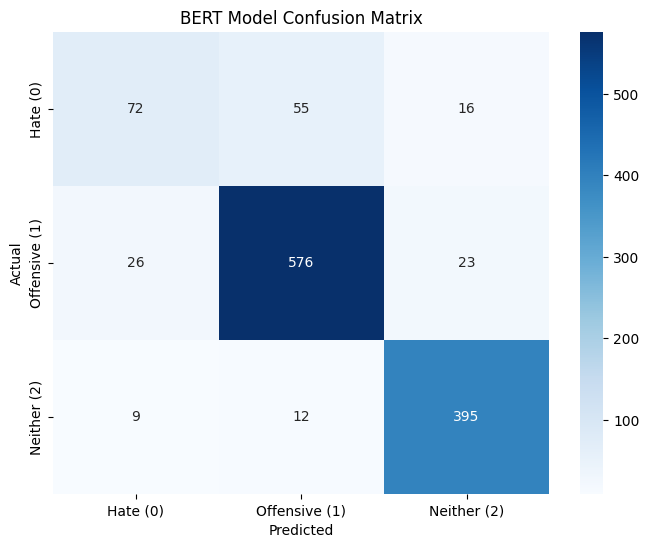


Classification Report:
              precision    recall  f1-score   support

        Hate       0.67      0.50      0.58       143
   Offensive       0.90      0.92      0.91       625
     Neither       0.91      0.95      0.93       416

    accuracy                           0.88      1184
   macro avg       0.83      0.79      0.80      1184
weighted avg       0.87      0.88      0.88      1184

------------------------------
PROPOSAL METRICS (Focus on Class 0: Hate Speech):
Hate Speech Recall: 0.5035
Hate Speech F2-Score: 0.5302
------------------------------


In [ ]:
# Confusion Matrix
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Hate (0)', 'Offensive (1)', 'Neither (2)'],
            yticklabels=['Hate (0)', 'Offensive (1)', 'Neither (2)'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('BERT Model Confusion Matrix')
plt.show()

# Classification Report with F2 Score Calculation
print("\nClassification Report:")
print(classification_report(labels, preds, target_names=['Hate', 'Offensive', 'Neither']))

# Specific Logic for Proposal Requirement: High Recall & F2 for Hate Speech
precision, recall, fbeta, support = precision_recall_fscore_support(labels, preds, beta=2, average=None)

print("-" * 30)
print("PROPOSAL METRICS (Focus on Class 0: Hate Speech):")
print(f"Hate Speech Recall: {recall[0]:.4f}")
print(f"Hate Speech F2-Score: {fbeta[0]:.4f}")
print("-" * 30)


model.save_pretrained("./hate_speech_bert_model")

model 1: Multinomial Naive Bayes

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import fbeta_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Feature Extraction (TF-IDF)
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(hate_speech_train['cleaned_tweet'])
X_val_tfidf = tfidf.transform(hate_speech_val['cleaned_tweet'])
X_test_tfidf = tfidf.transform(hate_speech_test['cleaned_tweet'])

y_train = hate_speech_train['class']
y_val = hate_speech_val['class']
y_test = hate_speech_test['class']

# 2. Hyperparameter Tuning (Smoothing Alpha)
alphas = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
best_alpha = 1.0
best_f2 = 0.0

print("Tuning Naive Bayes Alpha...")
for alpha in alphas:
    mnb = MultinomialNB(alpha=alpha)
    mnb.fit(X_train_tfidf, y_train)
    val_preds = mnb.predict(X_val_tfidf)

    # Calculate F2 score specifically for Class 0 (Hate Speech)
    f2 = fbeta_score(y_val, val_preds, beta=2, average=None)[0]

    print(f"Alpha: {alpha} | Hate Speech F2-Score: {f2:.4f}")

    if f2 > best_f2:
        best_f2 = f2
        best_alpha = alpha

print(f"\nBest Alpha found: {best_alpha}")

# 3. Final Training & Evaluation
mnb_final = MultinomialNB(alpha=best_alpha)
mnb_final.fit(X_train_tfidf, y_train)
mnb_preds = mnb_final.predict(X_test_tfidf)

# Metrics for Comparison later
mnb_metrics = precision_recall_fscore_support(y_test, mnb_preds, beta=2, average=None)
mnb_hate_recall = mnb_metrics[1][0] # Recall for Class 0
mnb_hate_f2 = mnb_metrics[2][0]     # F2 for Class 0

print("\n--- Model 1: Naive Bayes Results ---")
print(f"Hate Speech Recall: {mnb_hate_recall:.4f}")
print(f"Hate Speech F2:     {mnb_hate_f2:.4f}")
print(classification_report(y_test, mnb_preds, target_names=['Hate', 'Offensive', 'Neither']))

Tuning Naive Bayes Alpha...
Alpha: 0.01 | Hate Speech F2-Score: 0.3135
Alpha: 0.1 | Hate Speech F2-Score: 0.2627
Alpha: 0.5 | Hate Speech F2-Score: 0.1993
Alpha: 1.0 | Hate Speech F2-Score: 0.1105
Alpha: 5.0 | Hate Speech F2-Score: 0.0000
Alpha: 10.0 | Hate Speech F2-Score: 0.0000

Best Alpha found: 0.01

--- Model 1: Naive Bayes Results ---
Hate Speech Recall: 0.2308
Hate Speech F2:     0.2574
              precision    recall  f1-score   support

        Hate       0.48      0.23      0.31       143
   Offensive       0.75      0.89      0.81       625
     Neither       0.84      0.74      0.78       416

    accuracy                           0.76      1184
   macro avg       0.69      0.62      0.64      1184
weighted avg       0.75      0.76      0.74      1184



model 2: Feed Forward Neural Network

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 96.2 MB/s eta 0:00:00


In [ ]:
import gensim.downloader as api
from gensim.models import KeyedVectors
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# 1. Load Embeddings
print("Loading GoogleNews-vectors-negative300... (This may take a few minutes)")
try:
    # Try loading from Kaggle input
    word2vec_path = '/kaggle/input/googlenewsvectorsnegative300/GoogleNews-vectors-negative300.bin'
    if os.path.exists(word2vec_path):
        w2v_model = KeyedVectors.load_word2vec_format(word2vec_path, binary=True)
        print("Loaded from local/Kaggle path.")
    else:
        # Download using Gensim API
        w2v_model = api.load('word2vec-google-news-300')
        print("Downloaded and loaded from Gensim API.")
except Exception as e:
    print(f"Error loading Word2Vec: {e}")

# 2. Preprocessing: Convert Tweets to Averaged Vectors
def tweet_to_vector(tweet, model):
    words = str(tweet).split()
    word_vecs = [model[w] for w in words if w in model]
    if len(word_vecs) == 0:
        return np.zeros(300)
    return np.mean(word_vecs, axis=0)

print("Vectorizing datasets...")
X_train_w2v = np.array([tweet_to_vector(t, w2v_model) for t in hate_speech_train['cleaned_tweet']])
X_val_w2v = np.array([tweet_to_vector(t, w2v_model) for t in hate_speech_val['cleaned_tweet']])
X_test_w2v = np.array([tweet_to_vector(t, w2v_model) for t in hate_speech_test['cleaned_tweet']])

# Convert to PyTorch Tensors
train_data = TensorDataset(torch.FloatTensor(X_train_w2v), torch.LongTensor(y_train.to_numpy()))
val_data = TensorDataset(torch.FloatTensor(X_val_w2v), torch.LongTensor(y_val.to_numpy()))
test_data = TensorDataset(torch.FloatTensor(X_test_w2v), torch.LongTensor(y_test.to_numpy()))

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

# 3. Define FFNN Architecture
class HateSpeechFFNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(HateSpeechFFNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(hidden_dim, 64) # Second hidden layer
        self.fc3 = nn.Linear(64, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x

# Initialize Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ffnn_model = HateSpeechFFNN(300, 128, 3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(ffnn_model.parameters(), lr=0.001)

# 4. Training Loop
print("Starting FFNN Training...")
epochs = 10
best_val_loss = float('inf')

for epoch in range(epochs):
    ffnn_model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = ffnn_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    # Validation
    ffnn_model.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = ffnn_model(inputs)
            val_loss += criterion(outputs, labels).item()

    # Simple early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(ffnn_model.state_dict(), 'best_ffnn.pth')

print("FFNN Training Complete.")

# 5. Evaluate FFNN
ffnn_model.load_state_dict(torch.load('best_ffnn.pth'))
ffnn_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = ffnn_model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Metrics
ffnn_metrics = precision_recall_fscore_support(all_labels, all_preds, beta=2, average=None)
ffnn_hate_recall = ffnn_metrics[1][0]
ffnn_hate_f2 = ffnn_metrics[2][0]

print("\n--- Model 2: FFNN Results ---")
print(f"Hate Speech Recall: {ffnn_hate_recall:.4f}")
print(f"Hate Speech F2:     {ffnn_hate_f2:.4f}")
print(classification_report(all_labels, all_preds, target_names=['Hate', 'Offensive', 'Neither']))

Loading GoogleNews-vectors-negative300... (This may take a few minutes)
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Downloaded and loaded from Gensim API.
Vectorizing datasets...
Starting FFNN Training...
FFNN Training Complete.

--- Model 2: FFNN Results ---
Hate Speech Recall: 0.3427
Hate Speech F2:     0.3758
              precision    recall  f1-score   support

        Hate       0.61      0.34      0.44       143
   Offensive       0.87      0.90      0.88       625
     Neither       0.83      0.92      0.87       416

    accuracy                           0.84      1184
   macro avg       0.77      0.72      0.73      1184
weighted avg       0.82      0.84      0.83      1184



comparison

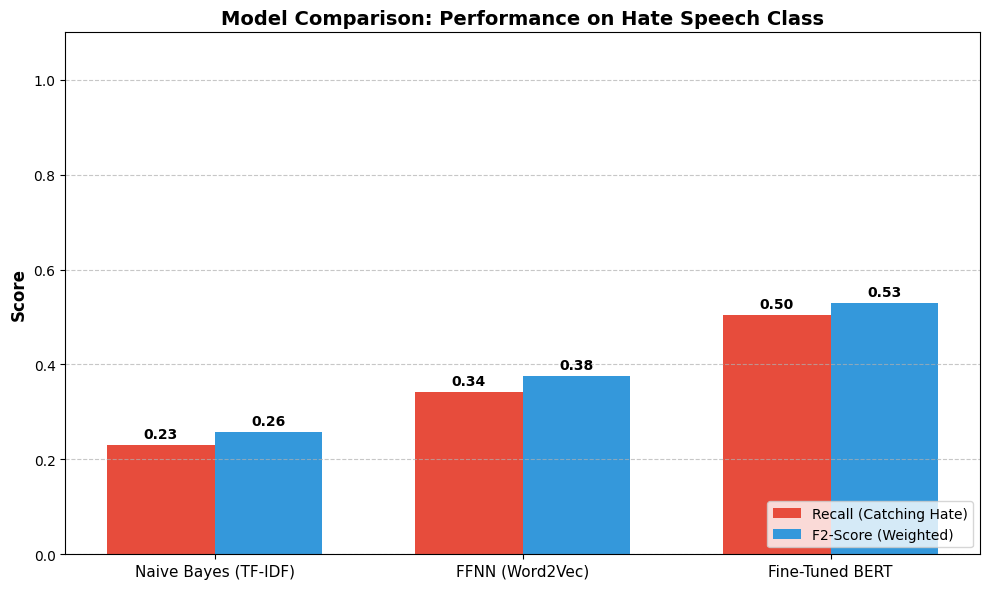


FINAL SUMMARY TABLE:
                  Model  Hate Speech Recall  Hate Speech F2-Score
0  Naive Bayes (TF-IDF)            0.230769              0.257410
1       FFNN (Word2Vec)            0.342657              0.375767
2       Fine-Tuned BERT            0.503497              0.530191


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support


try:
    bert_labels = predictions.label_ids
    bert_preds = np.argmax(predictions.predictions, axis=-1)

    # Calculate BERT metrics again with the CORRECT shapes
    bert_metrics = precision_recall_fscore_support(bert_labels, bert_preds, beta=2, average=None)
    bert_hate_recall = bert_metrics[1][0]
    bert_hate_f2 = bert_metrics[2][0]

except NameError:
    print("⚠️ 'predictions' object not found. Please re-run the BERT 'Evaluation' block first.")
    # Set placeholders to avoid crash if user is debugging
    bert_hate_recall = 0
    bert_hate_f2 = 0

# --- Create Comparison DataFrame ---
try:
    comparison_data = {
        'Model': ['Naive Bayes (TF-IDF)', 'FFNN (Word2Vec)', 'Fine-Tuned BERT'],
        'Hate Speech Recall': [mnb_hate_recall, ffnn_hate_recall, bert_hate_recall],
        'Hate Speech F2-Score': [mnb_hate_f2, ffnn_hate_f2, bert_hate_f2]
    }

    df_comparison = pd.DataFrame(comparison_data)

    # --- Visualization ---
    plt.style.use('default') # Reset style to default to avoid conflicts
    fig, ax = plt.subplots(figsize=(10, 6))

    x = np.arange(len(df_comparison['Model']))
    width = 0.35

    # Plotting the bars
    rects1 = ax.bar(x - width/2, df_comparison['Hate Speech Recall'], width, label='Recall (Catching Hate)', color='#e74c3c')
    rects2 = ax.bar(x + width/2, df_comparison['Hate Speech F2-Score'], width, label='F2-Score (Weighted)', color='#3498db')

    # Formatting
    ax.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax.set_title('Model Comparison: Performance on Hate Speech Class', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(df_comparison['Model'], fontsize=11)
    ax.legend(loc='lower right')
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Add value labels on top of bars
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontweight='bold')

    autolabel(rects1)
    autolabel(rects2)

    plt.tight_layout()
    plt.show()

    print("\nFINAL SUMMARY TABLE:")
    print(df_comparison)

except NameError as e:
    print(f"\n❌ MISSING DATA ERROR: {e}")
    print("Please make sure you have run the code for ALL THREE models in this session.")